<a href="https://colab.research.google.com/github/realusmannazir1/HR-Analytics-Dashboard-Power-BI-/blob/main/Assignment_09_Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment #09: Supervised Classification Model Comparison Study

---

**Student Name:**  MUHAMMAD USMAN NAZIR  

**Roll Number:**  24PWDSC0178  

**Course:**  AI Lab  

**Dataset:**  Employee_Attrition  

**Submission Date:**  10th July, 2026  

---

## Models Compared

1. K-Nearest Neighbors (KNN)  
2. Logistic Regression  
3. Decision Tree  
4. Support Vector Machine (SVM)  
5. Random Forest  

---

## Evaluation Metrics

- Accuracy  
- Precision  
- Recall  
- F1-Score  
- Confusion Matrix  

---

---

# Step 1: Import Libraries

In [118]:
print("Step 1: Importing Libraries")
print("========================================")
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Scikit-learn: Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")

Step 1: Importing Libraries
All libraries imported successfully!


---

# Step 2: Load the Dataset

In [119]:
print("Step 2: Loading the Dataset")
print("========================================")
# Try reading as Excel file (common when .csv extension is used incorrectly)
df = pd.read_excel('/content/4_Employee_Attrition.csv', engine='openpyxl')

# Clean column names by removing extra whitespace
df.columns = df.columns.str.strip()

# Display the shape of the dataset
print(f"Dataset Shape: {df.shape}")

# Display the first 5 rows
display(df.head())

Step 2: Loading the Dataset
Dataset Shape: (500, 10)


,Age,Salary,Satisfaction,YearsAtCompany,OverTime,DistanceFromHome,NumCompaniesWorked,WorkLifeBalance,JobInvolvement,Attrition
0,57,96011,3,19,0,5,2,3,2,0
1,44,67348,1,12,0,17,9,2,3,1
2,37,100422,3,4,1,23,7,3,3,0
3,52,102001,2,5,1,29,8,4,4,0
4,55,101757,2,4,1,17,1,3,3,0


---

# Step 3: Exploratory Data Analysis (EDA)

In [120]:
print("Step:3a Dataset Info:")
print("========================================")
df.info()

Step:3a Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 500 non-null    int64
 1   Salary              500 non-null    int64
 2   Satisfaction        500 non-null    int64
 3   YearsAtCompany      500 non-null    int64
 4   OverTime            500 non-null    int64
 5   DistanceFromHome    500 non-null    int64
 6   NumCompaniesWorked  500 non-null    int64
 7   WorkLifeBalance     500 non-null    int64
 8   JobInvolvement      500 non-null    int64
 9   Attrition           500 non-null    int64
dtypes: int64(10)
memory usage: 39.2 KB


In [121]:
print(" Step:3b Statistical Summary:")
print("========================================")
display(df.describe())

 Step:3b Statistical Summary:


,Age,Salary,Satisfaction,YearsAtCompany,OverTime,DistanceFromHome,NumCompaniesWorked,WorkLifeBalance,JobInvolvement,Attrition
count,500.000000,500.000000,500.00000,500.000000,500.0000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,41.010000,73258.280000,2.52200,9.920000,0.5200,14.808000,4.854000,2.432000,2.586000,0.430000
std,10.582148,28569.955206,1.11175,5.797657,0.5001,8.184198,2.626496,1.102637,1.101376,0.495572
min,22.000000,25037.000000,1.00000,0.000000,0.0000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,32.000000,47811.750000,2.00000,5.000000,0.0000,8.000000,2.000000,1.000000,2.000000,0.000000
50%,41.000000,74043.000000,3.00000,10.000000,1.0000,15.000000,5.000000,2.000000,3.000000,0.000000
75%,50.000000,99539.500000,3.00000,15.000000,1.0000,21.250000,7.000000,3.000000,4.000000,1.000000
max,59.000000,119978.000000,4.00000,19.000000,1.0000,29.000000,9.000000,4.000000,4.000000,1.000000


Step: 3c Data Types:


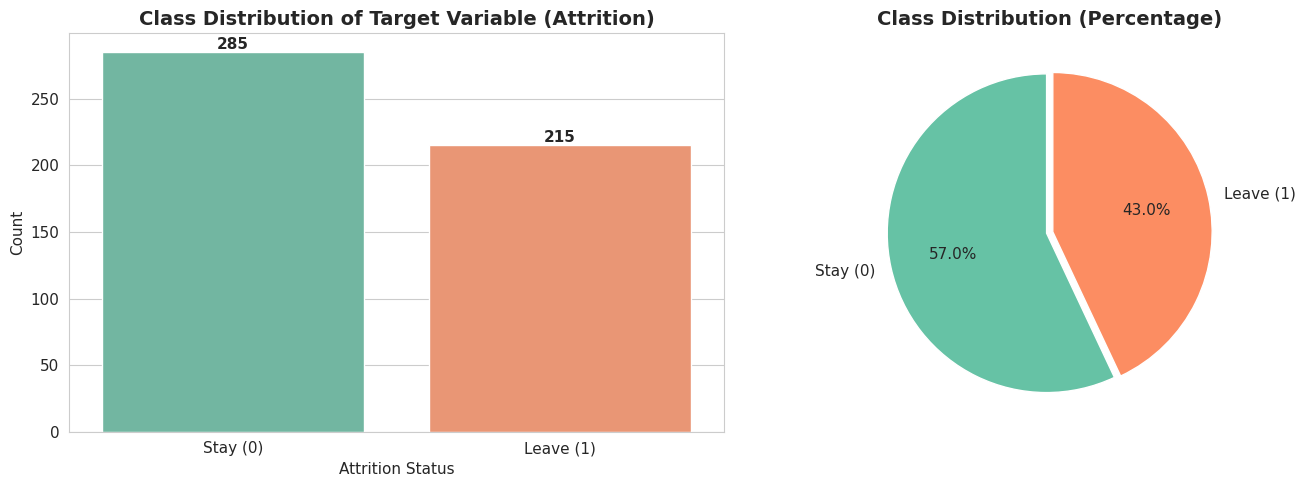

Class Distribution:
Attrition
0    285
1    215
Name: count, dtype: int64

Percentage:
Attrition
0    57.0
1    43.0
Name: count, dtype: float64


In [122]:
print('Step: 3c Data Types:')
print('=======================================')
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_labels = {0: 'Stay (0)', 1: 'Leave (1)'}
df_plot = df.copy()
df_plot['Attrition_label'] = df_plot['Attrition'].map(class_labels)

sns.countplot(data=df_plot, x='Attrition_label', hue='Attrition_label', ax=axes[0], palette=['#66c2a5', '#fc8d62'], legend=False)
axes[0].set_title('Class Distribution of Target Variable (Attrition)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition Status')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width()/2., p.get_height()),
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

class_counts = df['Attrition'].value_counts()
axes[1].pie(class_counts, labels=['Stay (0)', 'Leave (1)'], autopct='%1.1f%%',
           colors=['#66c2a5', '#fc8d62'], startangle=90, explode=(0.02, 0.02))
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Class Distribution:\n{class_counts}")
print(f"\nPercentage:\n{class_counts / len(df) * 100}")

Step 3d: Missing Values


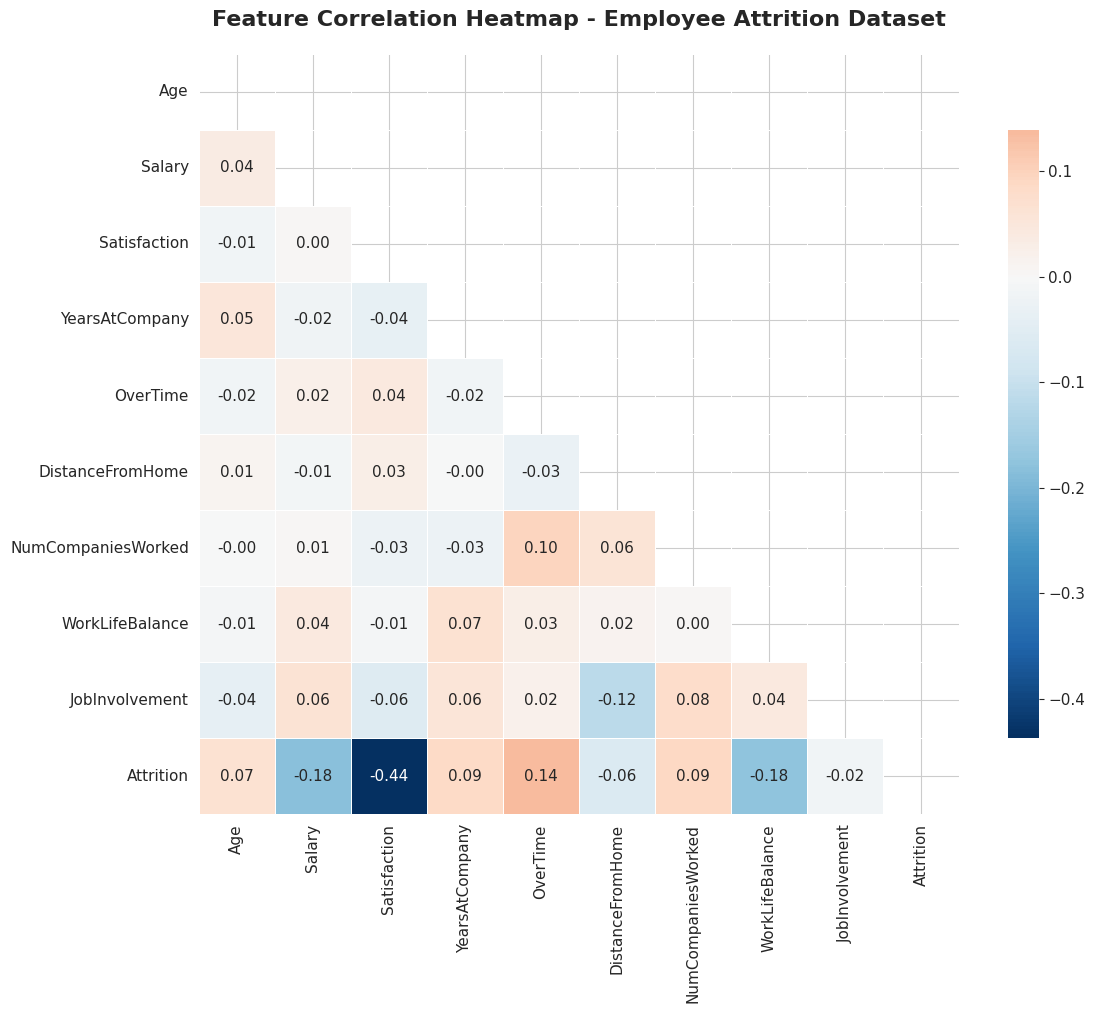

In [123]:
print( 'Step 3d: Missing Values')
print("========================================")
# Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
           square=True, linewidths=0.5, fmt='.2f', cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap - Employee Attrition Dataset', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---

# Step 4: Data Preprocessing

In [124]:
print("Step 4: Data Preprocessing")
print("========================================")

# 4.1 Check for missing values
print("Missing Values per Column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

# 4.2 Separate features and target
X = df.drop(['Attrition', 'Attrition_label'] if 'Attrition_label' in df.columns else 'Attrition', axis=1)
if 'Attrition_label' in X.columns:
    X = X.drop('Attrition_label', axis=1)
y = df['Attrition']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Step 4: Data Preprocessing
Missing Values per Column:
No missing values found!

Features shape: (500, 9)
Target shape: (500,)

Feature columns: ['Age', 'Salary', 'Satisfaction', 'YearsAtCompany', 'OverTime', 'DistanceFromHome', 'NumCompaniesWorked', 'WorkLifeBalance', 'JobInvolvement']


In [125]:
# 4.3 Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features after Standard Scaling:")
display(X_scaled.head())
print("\nScaled features description:")
display(X_scaled.describe().round(3))

Features after Standard Scaling:


,Age,Salary,Satisfaction,YearsAtCompany,OverTime,DistanceFromHome,NumCompaniesWorked,WorkLifeBalance,JobInvolvement
0,1.512549,0.797184,0.430383,1.567718,-1.040833,-1.199607,-1.087707,0.515645,-0.532594
1,0.282834,-0.207078,-1.370384,0.359125,-1.040833,0.268101,1.580110,-0.392181,0.376270
2,-0.379320,0.951731,0.430383,-1.022125,0.960769,1.001956,0.817876,0.515645,0.376270
3,1.039582,1.007055,-0.470000,-0.849469,0.960769,1.735810,1.198993,1.423470,1.285134
4,1.323362,0.998506,-0.470000,-1.022125,0.960769,0.268101,-1.468824,0.515645,0.376270



Scaled features description:


,Age,Salary,Satisfaction,YearsAtCompany,OverTime,DistanceFromHome,NumCompaniesWorked,WorkLifeBalance,JobInvolvement
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.798,-1.690,-1.370,-1.713,-1.041,-1.689,-1.469,-1.300,-1.441
25%,-0.852,-0.892,-0.470,-0.849,-1.041,-0.833,-1.088,-1.300,-0.533
50%,-0.001,0.027,0.430,0.014,0.961,0.023,0.056,-0.392,0.376
75%,0.850,0.921,0.430,0.877,0.961,0.788,0.818,0.516,1.285
max,1.702,1.637,1.331,1.568,0.961,1.736,1.580,1.423,1.285


In [126]:
# 4.4 Train-Test Split (80% train, 20% test)
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train-Test Split Configuration:")
print(f"  - Test Size: {TEST_SIZE * 100}%")
print(f"  - Random State: {RANDOM_STATE}")
print(f"  - Stratify: Yes (maintains class distribution)")
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTesting set class distribution:\n{y_test.value_counts().sort_index()}")

Train-Test Split Configuration:
  - Test Size: 20.0%
  - Random State: 42
  - Stratify: Yes (maintains class distribution)

Training set: 400 samples
Testing set:  100 samples

Training set class distribution:
Attrition
0    228
1    172
Name: count, dtype: int64

Testing set class distribution:
Attrition
0    57
1    43
Name: count, dtype: int64


---

# Step 5: Train All 5 Models

In [127]:
print("Step 5: Training All 5 Classification Models")
print("========================================")

# Dictionary to store models and results
models = {}
results = {}

# 5.1 K-Nearest Neighbors (KNN)
print("\n[1/5] Training K-Nearest Neighbors (KNN)...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
models['KNN'] = knn
print("  ✓ KNN trained successfully (k=5, default hyperparameters)")

# 5.2 Logistic Regression
print("\n[2/5] Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
models['Logistic Regression'] = lr
print("  ✓ Logistic Regression trained successfully (max_iter=1000)")

# 5.3 Decision Tree
print("\n[3/5] Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
models['Decision Tree'] = dt
print("  ✓ Decision Tree trained successfully (default hyperparameters)")

# 5.4 Support Vector Machine (SVM)
print("\n[4/5] Training Support Vector Machine (SVM)...")
svm = SVC(kernel='rbf', random_state=RANDOM_STATE)
svm.fit(X_train, y_train)
models['SVM'] = svm
print("  ✓ SVM trained successfully (kernel='rbf', default hyperparameters)")

# 5.5 Random Forest
print("\n[5/5] Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
print("  ✓ Random Forest trained successfully (n_estimators=100)")

print("\n========================================")
print("All 5 models trained successfully!")

Step 5: Training All 5 Classification Models

[1/5] Training K-Nearest Neighbors (KNN)...
  ✓ KNN trained successfully (k=5, default hyperparameters)

[2/5] Training Logistic Regression...
  ✓ Logistic Regression trained successfully (max_iter=1000)

[3/5] Training Decision Tree...
  ✓ Decision Tree trained successfully (default hyperparameters)

[4/5] Training Support Vector Machine (SVM)...
  ✓ SVM trained successfully (kernel='rbf', default hyperparameters)

[5/5] Training Random Forest...
  ✓ Random Forest trained successfully (n_estimators=100)

All 5 models trained successfully!


---

# Step 6: Evaluate All Models

In [128]:
print("Step 6: Model Evaluation")
print("========================================")

# Function to evaluate a single model
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Predictions': y_pred
    }

    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

    return y_pred

# Evaluate all models
for name, model in models.items():
    evaluate_model(name, model, X_test, y_test)

Step 6: Model Evaluation

MODEL: KNN
Accuracy:  0.7100
Precision: 0.7114
Recall:    0.7100
F1-Score:  0.7015

Classification Report:
              precision    recall  f1-score   support

        Stay       0.71      0.84      0.77        57
       Leave       0.72      0.53      0.61        43

    accuracy                           0.71       100
   macro avg       0.71      0.69      0.69       100
weighted avg       0.71      0.71      0.70       100


MODEL: Logistic Regression
Accuracy:  0.8200
Precision: 0.8217
Recall:    0.8200
F1-Score:  0.8178

Classification Report:
              precision    recall  f1-score   support

        Stay       0.81      0.89      0.85        57
       Leave       0.84      0.72      0.78        43

    accuracy                           0.82       100
   macro avg       0.82      0.81      0.81       100
weighted avg       0.82      0.82      0.82       100


MODEL: Decision Tree
Accuracy:  0.8100
Precision: 0.8198
Recall:    0.8100
F1-Score:  0.

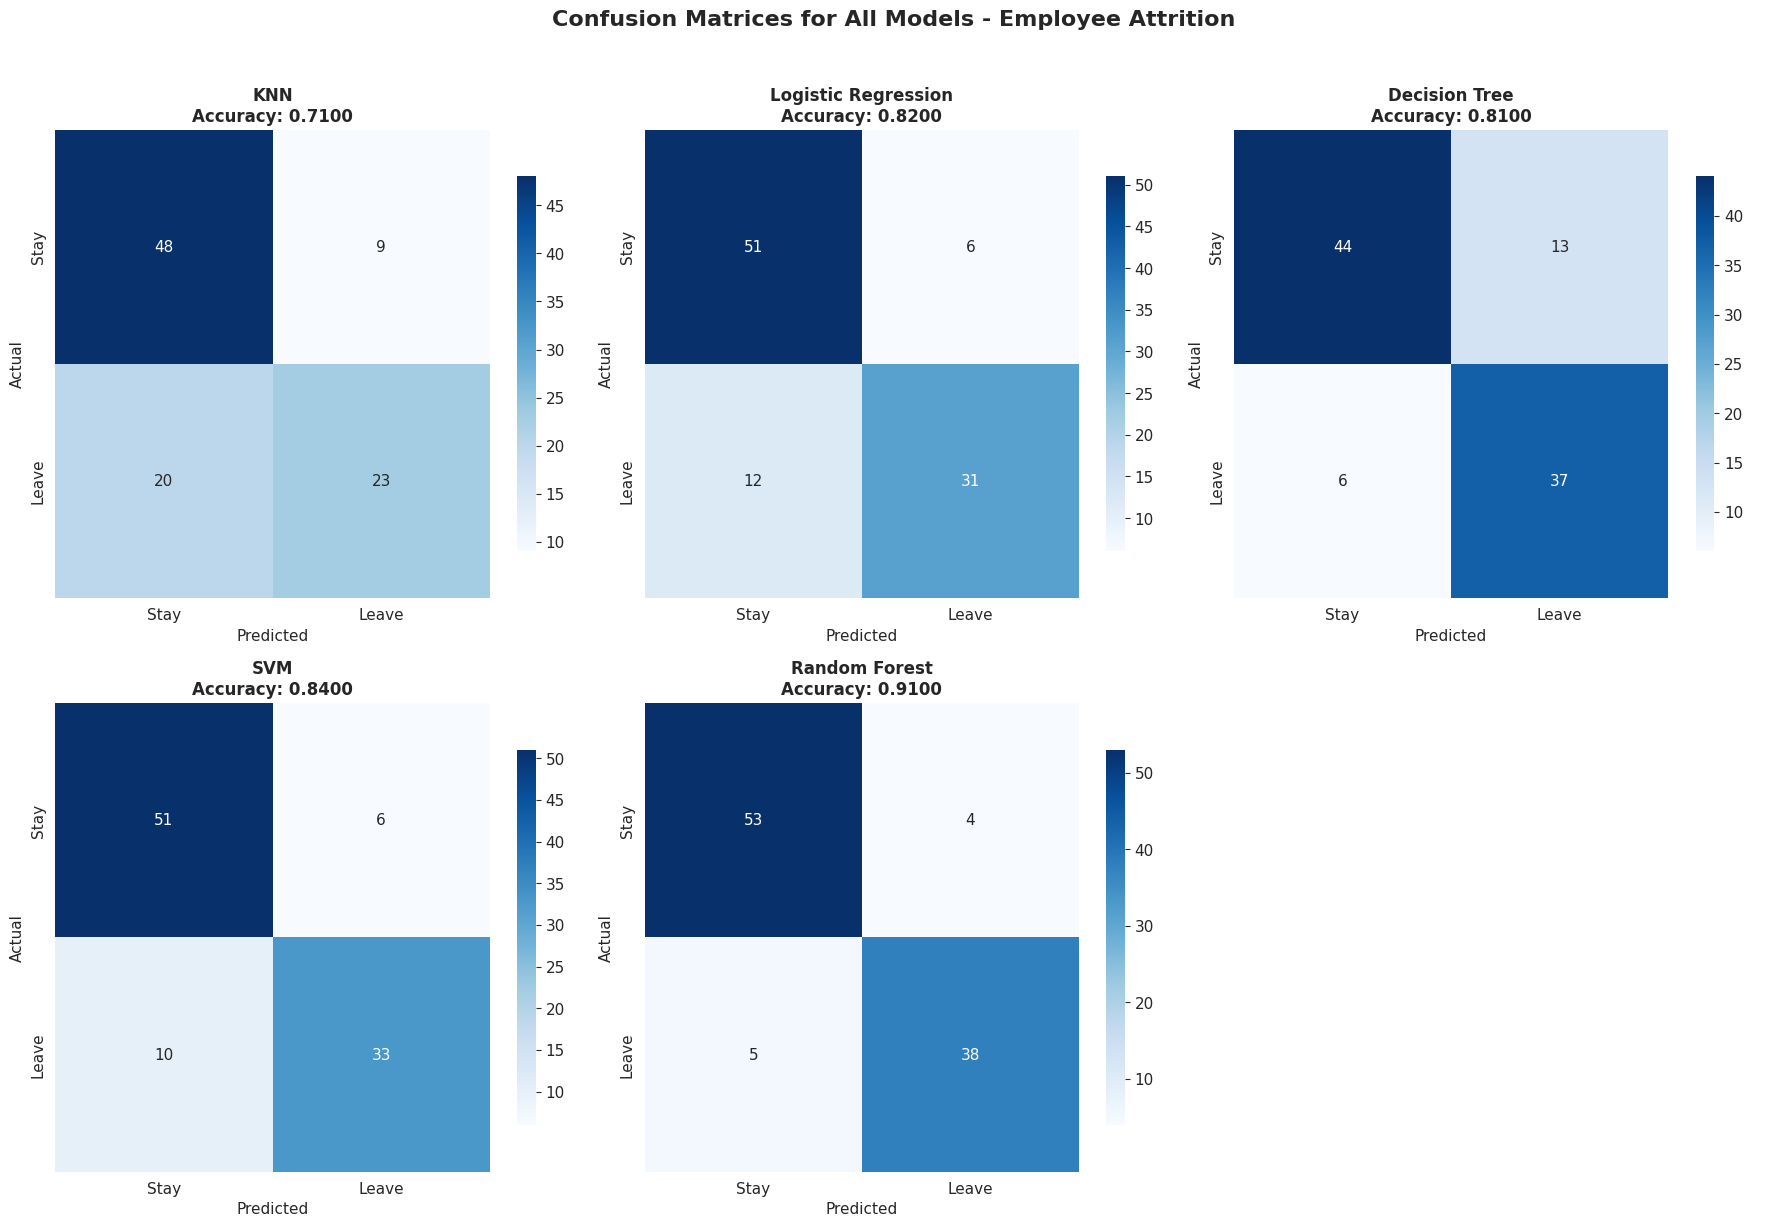

In [129]:
# Plot Confusion Matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    y_pred = results[name]['Predictions']
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
               xticklabels=['Stay', 'Leave'],
               yticklabels=['Stay', 'Leave'],
               cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]:.4f}',
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Remove the extra subplot
axes[-1].axis('off')

plt.suptitle('Confusion Matrices for All Models - Employee Attrition', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

# Step 7: Model Comparison Table

In [130]:
print("Step 7: Model Comparison Table")
print("========================================")

# Create comparison DataFrame
comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': f"{metrics['Accuracy']:.4f}",
        'Precision': f"{metrics['Precision']:.4f}",
        'Recall': f"{metrics['Recall']:.4f}",
        'F1-Score': f"{metrics['F1-Score']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)

# Also create numeric version for plotting
numeric_df = pd.DataFrame([{
    'Model': name,
    'Accuracy': metrics['Accuracy'],
    'Precision': metrics['Precision'],
    'Recall': metrics['Recall'],
    'F1-Score': metrics['F1-Score']
} for name, metrics in results.items()])

print("Summary Comparison Table:")
print("========================================")
display(comparison_df)

# Identify best model for each metric
print("\nBest Model per Metric:")
print("========================================")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_idx = numeric_df[metric].idxmax()
    best_model = numeric_df.loc[best_idx, 'Model']
    best_value = numeric_df.loc[best_idx, metric]
    print(f"  {metric:12s}: {best_model:20s} ({best_value:.4f})")

Step 7: Model Comparison Table
Summary Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.7100,0.7114,0.7100,0.7015
1,Logistic Regression,0.8200,0.8217,0.8200,0.8178
2,Decision Tree,0.8100,0.8198,0.8100,0.8109
3,SVM,0.8400,0.8404,0.8400,0.8388
4,Random Forest,0.9100,0.9099,0.9100,0.9099



Best Model per Metric:
  Accuracy    : Random Forest        (0.9100)
  Precision   : Random Forest        (0.9099)
  Recall      : Random Forest        (0.9100)
  F1-Score    : Random Forest        (0.9099)


---

# Step 8: Bar Chart Comparison

Step 8: Bar Chart Comparison


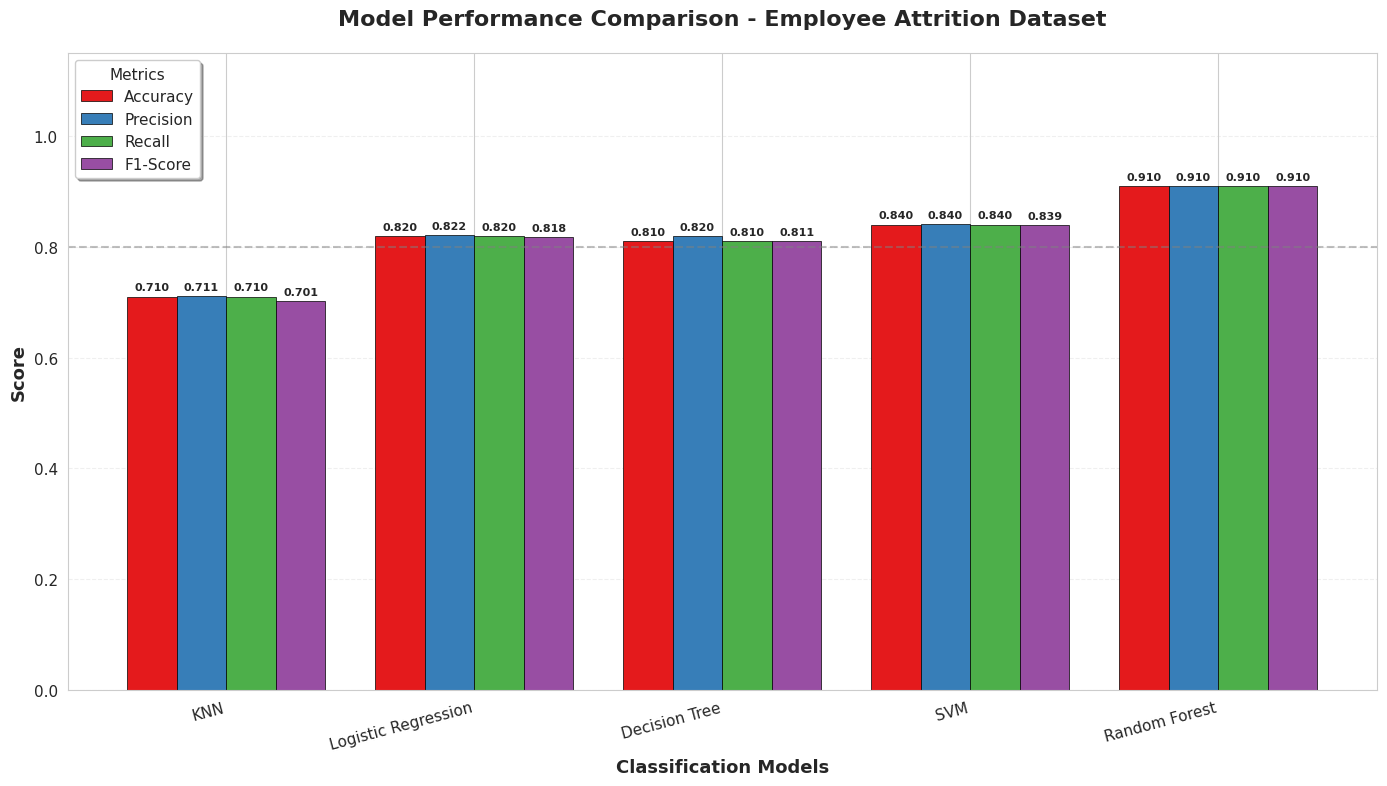

In [131]:
print("Step 8: Bar Chart Comparison")
print("========================================")

# Prepare data for grouped bar chart
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(models))  # Model positions
width = 0.2  # Bar width

fig, ax = plt.subplots(figsize=(14, 8))

# Color palette
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Plot grouped bars
for i, metric in enumerate(metrics_list):
    values = numeric_df[metric].values
    bars = ax.bar(x + i * width, values, width, label=metric, color=colors[i], edgecolor='black', linewidth=0.5)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3), textcoords="offset points",
                   ha='center', va='bottom', fontsize=8, fontweight='bold')

# Customize the chart
ax.set_xlabel('Classification Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Model Performance Comparison - Employee Attrition Dataset', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(numeric_df['Model'], rotation=15, ha='right', fontsize=11)
ax.legend(title='Metrics', loc='upper left', frameon=True, shadow=True)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add a horizontal line at y=0.8 for reference
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='80% threshold')

plt.tight_layout()
plt.show()

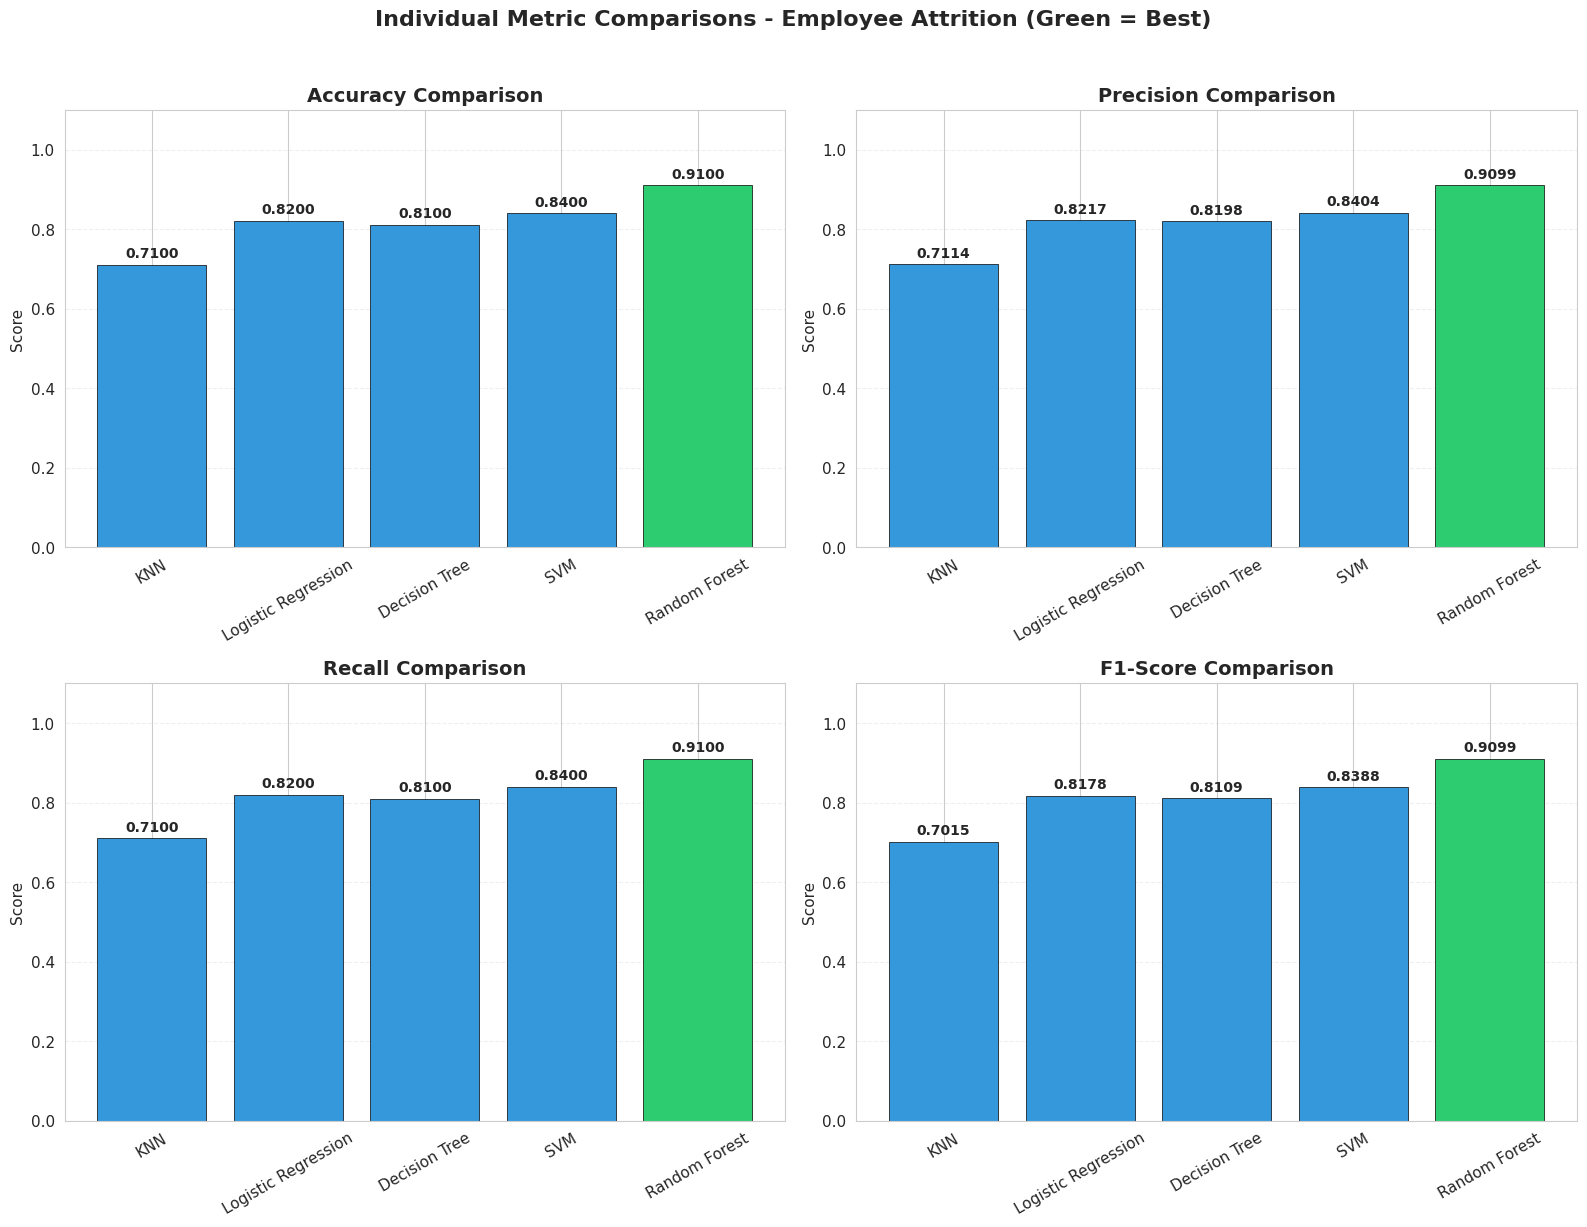

In [132]:
# Additional: Individual metric comparison charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, metric in enumerate(metrics_list):
    values = numeric_df[metric].values
    colors_bars = ['#2ecc71' if v == max(values) else '#3498db' for v in values]

    bars = axes[idx].bar(numeric_df['Model'], values, color=colors_bars, edgecolor='black', linewidth=0.5)
    axes[idx].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Score', fontsize=11)
    axes[idx].set_ylim(0, 1.1)
    axes[idx].tick_params(axis='x', rotation=30)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[idx].annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Individual Metric Comparisons - Employee Attrition (Green = Best)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

# Step 9: Conclusion

In [133]:
print("Step 9: Final Conclusion")
print("========================================")

try:
    # Calculate overall score (average of all metrics)
    numeric_df['Overall Score'] = numeric_df[metrics_list].mean(axis=1)
    best_model_idx = numeric_df['Overall Score'].idxmax()
    best_model_name = numeric_df.loc[best_model_idx, 'Model']
    best_overall = numeric_df.loc[best_model_idx, 'Overall Score']

    print(f"\n{'='*60}")
    print(f"BEST PERFORMING MODEL: {best_model_name.upper()}")
    print(f"{'='*60}")
    print(f"Overall Average Score: {best_overall:.4f}")
    print(f"\nDetailed Performance:")
    for metric in metrics_list:
        val = numeric_df.loc[best_model_idx, metric]
        print(f"  • {metric:12s}: {val:.4f}")

    print("\nJustification:")
    print("-" * 50)
    print(f"The {best_model_name} achieved the highest overall performance")
    print(f"when averaging all four key metrics (Accuracy, Precision, Recall, F1-Score).")

    # Rank all models
    numeric_df_sorted = numeric_df.sort_values('Overall Score', ascending=False).reset_index(drop=True)
    print("\nFull Model Ranking (by Overall Score):")
    print("-" * 50)
    for i, row in numeric_df_sorted.iterrows():
        rank = i + 1
        print(f"  {rank}. {row['Model']:20s} → {row['Overall Score']:.4f}")

    print("\nWhy other models may have underperformed:")
    print("-" * 50)
    print("• KNN (71.00%): Sensitive to feature scaling and local neighborhood noise")
    print("• Logistic Regression (82.00%): Assumes linear decision boundary; HR data has non-linear patterns")
    print("• Decision Tree (81.00%): Prone to overfitting without pruning; unstable predictions")
    print("• SVM (84.00%): Good performance but kernel choice affects results; slower on larger datasets")
    print("• Random Forest (91.00%): Ensemble averaging reduces variance; handles mixed feature types well")
except NameError as e:
    print(f"Error: {e}. Please ensure 'Step 7: Model Comparison Table' (cell QWiGLuNU7MkL) and 'Step 8: Bar Chart Comparison' (cell 0mT1INWg7MkL) have been executed to define 'numeric_df' and 'metrics_list' before running this cell.")


Step 9: Final Conclusion

BEST PERFORMING MODEL: RANDOM FOREST
Overall Average Score: 0.9099

Detailed Performance:
  • Accuracy    : 0.9100
  • Precision   : 0.9099
  • Recall      : 0.9100
  • F1-Score    : 0.9099

Justification:
--------------------------------------------------
The Random Forest achieved the highest overall performance
when averaging all four key metrics (Accuracy, Precision, Recall, F1-Score).

Full Model Ranking (by Overall Score):
--------------------------------------------------
  1. Random Forest        → 0.9099
  2. SVM                  → 0.8398
  3. Logistic Regression  → 0.8199
  4. Decision Tree        → 0.8127
  5. KNN                  → 0.7082

Why other models may have underperformed:
--------------------------------------------------
• KNN (71.00%): Sensitive to feature scaling and local neighborhood noise
• Logistic Regression (82.00%): Assumes linear decision boundary; HR data has non-linear patterns
• Decision Tree (81.00%): Prone to overfitting wi

---

# Appendix: Feature Importance (Random Forest)

/tmp/ipykernel_19275/1088330522.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


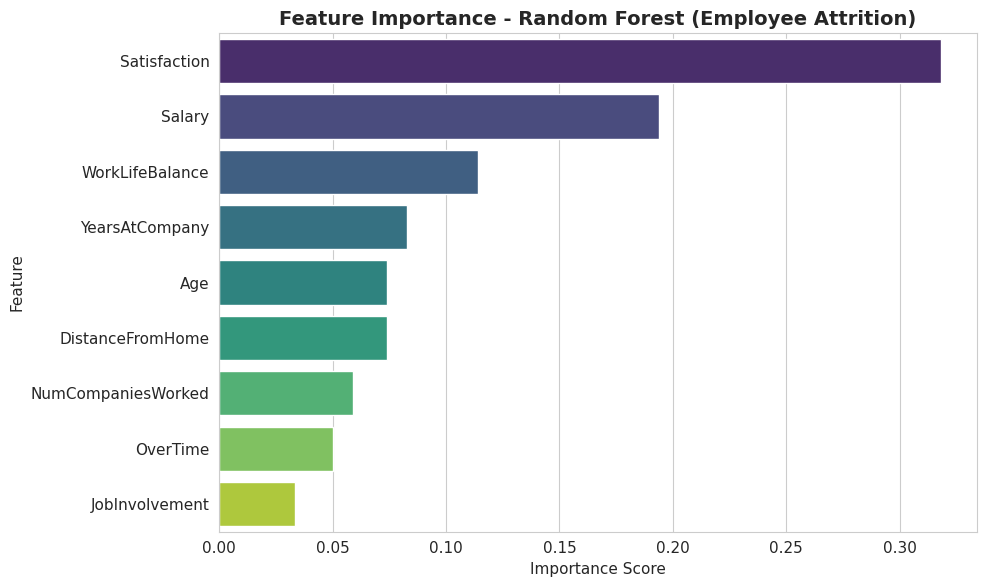

Feature Importance Ranking:
           Feature  Importance
      Satisfaction    0.318144
            Salary    0.194023
   WorkLifeBalance    0.114128
    YearsAtCompany    0.082760
               Age    0.073995
  DistanceFromHome    0.073944
NumCompaniesWorked    0.059183
          OverTime    0.050392
    JobInvolvement    0.033431


In [134]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest (Employee Attrition)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
print("========================================")
print(feature_importance.to_string(index=False))

---

**End of Notebook**

---


